In [5]:
# load bose data for stationary time-series methods: MA and SES
import pandas as pd
dfbose = pd.read_excel("../data/bose_data.xlsx")

In [10]:
dfbose

,week,demand
0,1,35
1,2,48
2,3,47
3,4,56
4,5,80
...,...,...
95,96,58
96,97,41
97,98,58
98,99,36


<Axes: xlabel='week'>

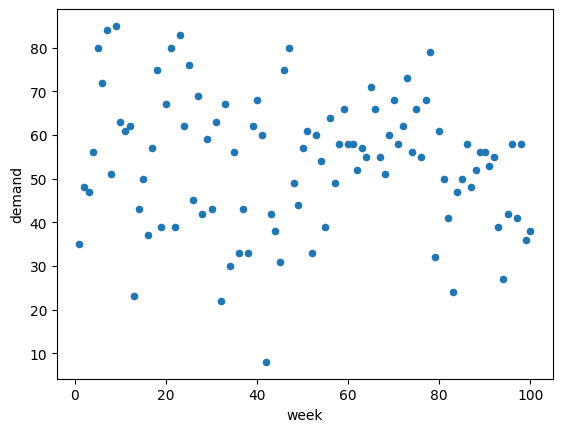

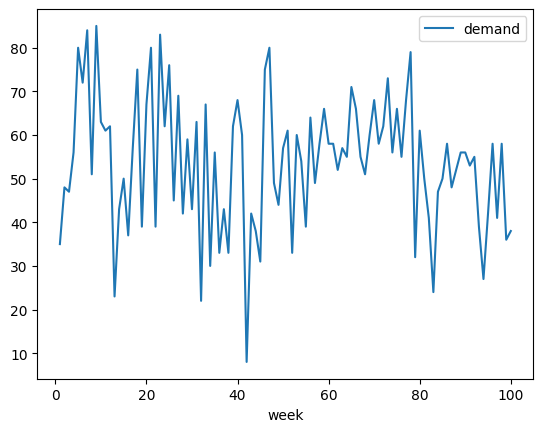

In [6]:
# eyeball the data
dfbose.plot.scatter(x="week",y="demand")
dfbose.plot.line(x="week",y="demand")

In [11]:
# 100 data points in total; 80-20 split
train_bose = dfbose[:80]

In [12]:
# difference in indexing base vs pandas
train_bose.demand[:10]
train_bose.loc[:10,"demand"]

0     35
1     48
2     47
3     56
4     80
5     72
6     84
7     51
8     85
9     63
10    61
Name: demand, dtype: int64

In [13]:
# use the rolling_mean function to compute rolling means
# note that rolling_mean on row 3 is equal to (row 1 + row 2 + row 3)/3
# this is the MA(3) forecast for row 4
train_bose.loc[:10,"demand"].rolling(3).mean()

0           NaN
1           NaN
2     43.333333
3     50.333333
4     61.000000
5     69.333333
6     78.666667
7     69.000000
8     73.333333
9     66.333333
10    69.666667
Name: demand, dtype: float64

In [14]:
## Moving Average method 

# MA(3) forecast for week 4 through 80
train_bose["demand"].rolling(3).mean()[2:79]

2     43.333333
3     50.333333
4     61.000000
5     69.333333
6     78.666667
        ...    
74    65.000000
75    59.000000
76    63.000000
77    67.333333
78    59.666667
Name: demand, Length: 77, dtype: float64

In [15]:
# Mean Squared Error of MA(3)
# check shape equivalence first
# actual for week 4 through week 80
train_bose.demand[3:].shape

(77,)

In [16]:
# MA(3) forecast for week 4 through week 80
train_bose["demand"].rolling(3).mean()[2:79].shape

(77,)

In [17]:
# compare the actual with forecast, summarize into MSE
from sklearn.metrics import mean_squared_error

mean_squared_error(train_bose.demand[3:],
                   train_bose["demand"].rolling(3).mean()[2:79]) # look closely at the indexing

298.1702741702742

In [18]:
# try N = 1 to 30; find the smallest MSE using grid search

# N = 8 is the best
for index in range(1,31):
    print([index,mean_squared_error(train_bose.demand[30:], 
                                    train_bose["demand"].rolling(index).mean()[29:79])])

[1, 448.52]
[2, 307.285]
[3, 285.28222222222223]
[4, 256.6325]
[5, 260.83600000000007]
[6, 230.96444444444444]
[7, 225.14244897959188]
[8, 216.27875]
[9, 232.18864197530863]
[10, 217.84560000000002]
[11, 228.73008264462808]
[12, 224.31736111111113]
[13, 224.61100591715976]
[14, 228.87826530612247]
[15, 231.78097777777776]
[16, 229.68375]
[17, 232.26920415224916]
[18, 232.5058024691358]
[19, 229.84354570637117]
[20, 229.25055]
[21, 232.11986394557826]
[22, 232.22256198347105]
[23, 231.29081285444238]
[24, 232.02218750000003]
[25, 235.20396800000003]
[26, 233.15325443786983]
[27, 237.4821399176955]
[28, 239.74497448979594]
[29, 239.58328180737217]
[30, 239.02713333333332]


In [19]:
# store MA(8) forecast in the testing/holdout sample: last 20 rows
dfbose.loc[80:, 'ma'] = train_bose["demand"].rolling(8).mean().iloc[-1]

In [20]:
dfbose

,week,demand,ma
0,1,35,NaN
1,2,48,NaN
2,3,47,NaN
3,4,56,NaN
4,5,80,NaN
...,...,...,...
95,96,58,61.25
96,97,41,61.25
97,98,58,61.25
98,99,36,61.25


In [22]:
## Simple Exponential Smoothing method
# training sample first 80 weeks
# allow 10 weeks of burn in period

from statsmodels.tsa.api import ExponentialSmoothing
# alpha needs to be between 0 and 1, use grid search
# range() only handles intergers, use arange from numpy
# alpha = 0 is the best
ExponentialSmoothing(train_bose.demand, initialization_method='estimated').fit(smoothing_level = 0.5).predict(10,79)

10    68.666637
11    64.833319
12    63.416659
13    43.208330
14    43.104165
        ...    
75    63.776650
76    59.388325
77    63.694162
78    71.347081
79    51.673541
Length: 70, dtype: float64

In [23]:
mean_squared_error(train_bose.demand[10:],
                   ExponentialSmoothing(train_bose.demand, initialization_method='estimated').fit(smoothing_level =0.5).predict(10,79))

308.7765445641979

In [24]:
import numpy as np
for alpha in np.arange(0.0, 1.1, 0.1):
    print([alpha,
           mean_squared_error(train_bose.demand[10:],ExponentialSmoothing(train_bose.demand, initialization_method='estimated').fit(smoothing_level = alpha).predict(10,79))])

[np.float64(0.0), 234.59765608369307]
[np.float64(0.1), 245.63216519900675]
[np.float64(0.2), 257.12437900477113]
[np.float64(0.30000000000000004), 271.7595104866501]
[np.float64(0.4), 288.65991904147677]
[np.float64(0.5), 308.7765445641979]
[np.float64(0.6000000000000001), 333.06986623009635]
[np.float64(0.7000000000000001), 362.4723869426851]
[np.float64(0.8), 398.09703183979906]
[np.float64(0.9), 441.4017679888638]
[np.float64(1.0), 494.4]


In [25]:
# store SES(0) in the test sample
# difference between .predict() vs .forecast()
dfbose.loc[80:, 'ses'] = ExponentialSmoothing(train_bose.demand, initialization_method='estimated').fit(smoothing_level = 0).forecast(20)

In [27]:
# compare MSE in the holdout sample for MA(8) and SES(0)
mean_squared_error(dfbose.demand[80:],dfbose.ma[80:])

316.7875

In [28]:
mean_squared_error(dfbose.demand[80:],dfbose.ses[80:])

179.4239046589236

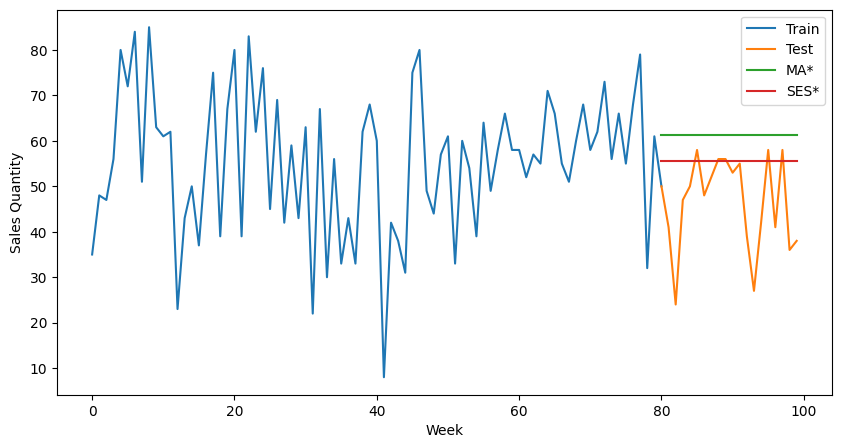

In [29]:
# plot forecast vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(dfbose.demand[:81], label='Train')
plt.plot(dfbose.demand[80:], label='Test')
plt.plot(dfbose.ma[80:], label='MA*')
plt.plot(dfbose.ses[80:], label='SES*')
plt.legend(loc='best')
plt.xlabel('Week')
plt.ylabel('Sales Quantity')
plt.show()


## Part 2

In [ ]:
# more details of time-series forecasting
# https://www.analyticsvidhya.com/blog/2018/02/time-series-forecasting-methods/
import pandas as pd

## Double ES method for dealing with trend
# load IE data
dfie = pd.read_excel("../data/ie_data.xlsx")

<Axes: xlabel='week'>

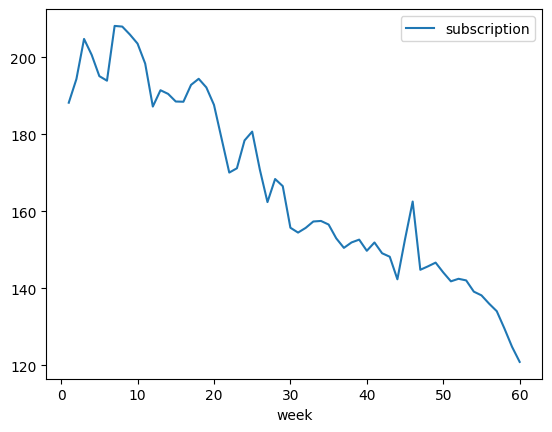

In [31]:
# eyeball test
dfie.plot.line(x="week",y="subscription")

In [33]:
# DF unit root test

# p-value > 0.05 -> not rejecting H1 -> nonstationary
from statsmodels.tsa.stattools import adfuller
ad_result = adfuller(dfie.subscription)

print('ADF Statistic: %f' % ad_result[0])
print('p-value: %f' % ad_result[1])

ADF Statistic: 0.053151
p-value: 0.962713


In [34]:
# training sample first 30 weeks
# allow 5 weeks of burn in period
# DES for weeks 6-30, given alpha and beta is calculated by
# alpha = smoothing_level, beta = smoothing_trend
from statsmodels.tsa.api import ExponentialSmoothing

ExponentialSmoothing(dfie.subscription[:30],trend="add", initialization_method='estimated').fit(smoothing_level = 0.3,smoothing_trend = 0.5).predict(5,29)


5     203.451940
6     200.675695
7     204.120969
8     207.062016
9     208.328446
10    207.796181
11    204.449667
12    196.177658
13    190.951603
14    186.942124
15    183.779670
16    182.251502
17    184.085559
18    187.395065
19    189.758959
20    189.739842
21    185.454483
22    177.510059
23    171.336954
24    170.247237
25    171.740850
26    169.699251
27    164.641744
28    163.462228
29    162.544732
dtype: float64

In [35]:
# write a function that takes alpha and beta as input and produces the traning sample MSE
from sklearn.metrics import mean_squared_error
import numpy as np

def DESMSE(alpha,beta):
    return mean_squared_error(dfie.subscription[5:30],
                              ExponentialSmoothing(dfie.subscription[:30],trend="add", initialization_method='estimated').fit(smoothing_level = alpha,smoothing_trend = beta).predict(5,29))
    

In [37]:
# test the function
print(DESMSE(0.5,0.5))
print(DESMSE(0.1,0.9))

60.54906966015499
53.086387846450506


In [38]:
# This time, we introduce a more formal approach to do grid search
# the function below allows you to construct a dataframe of alpha-beta combinations
from itertools import product
def expand_grid(dictionary):
   return pd.DataFrame([row for row in product(*dictionary.values())], 
                       columns=dictionary.keys())

In [39]:
# define the alpha and beta values to try as a dictionary
dictionary = {'alpha': np.arange(0.0, 1.01, 0.01), 
              'beta': np.arange(0.0, 1.01, 0.01)}

In [40]:
# construct alpha,beta values to try 
des_results = expand_grid(dictionary)

In [41]:
# add a column called mse, as a place holder for putting in the MSE results later
des_results["mse"] = np.repeat(0,len(des_results))

In [42]:
# now, we reuse the DESMSE function above to cycle through all alpha beta values.
# this is a giant loop, so let's time it!
import time
start = time.time()

for alpha in np.arange(0.0, 1.01, 0.01):
    for beta in np.arange(0.0, 1.01, 0.01):
       des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = DESMSE(alpha,beta)
    
end = time.time()
end-start

/var/folders/ns/52cz2xsx3nv_ncxwvhlz83_m0000gn/T/ipykernel_48537/2534022692.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.82332147747998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  des_results.loc[(des_results["alpha"] == alpha) & (des_results["beta"] == beta),"mse"] = DESMSE(alpha,beta)
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/gregoryknapp/Code/BU/BU-SP2026-BA875-Assignments/.venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:9

18.91969585418701

In [43]:
# find the best alpha beta
des_results.sort_values("mse").head(10)

,alpha,beta,mse
10100,1.00,0.00,36.633806
9999,0.99,0.00,36.736327
9898,0.98,0.00,36.839532
9797,0.97,0.00,36.943413
10101,1.00,0.01,37.041148
9696,0.96,0.00,37.047951
10000,0.99,0.01,37.146456
9595,0.95,0.00,37.153149
9899,0.98,0.01,37.252478
9494,0.94,0.00,37.259007


In [44]:
# alpha = 1, beta = 0.00
# store DES(1,0.00) in the test sample
dfie.loc[dfie.index[30:], 'des'] = ExponentialSmoothing(dfie.subscription[:30],trend="add", initialization_method='estimated').fit(smoothing_level = 1,smoothing_trend = 0.00).forecast(30)


In [45]:
# MSE in the holdout sample
mean_squared_error(dfie.subscription[30:],dfie.des[30:])

80.57377617567279

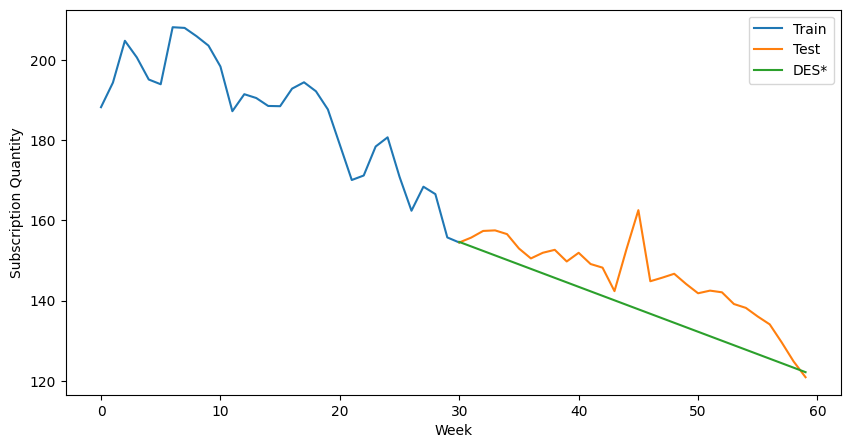

In [46]:
# plot forecast vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(dfie.subscription[:31], label='Train')
plt.plot(dfie.subscription[30:], label='Test')
plt.plot(dfie.des[30:], label='DES*')
plt.legend(loc='best')
plt.xlabel('Week')
plt.ylabel('Subscription Quantity')
plt.show()

In [48]:
## In Class Exercise 
# Moving Average and Simple Exponential Smoothing 
dfjeans = pd.read_excel("../data/jeans_data.xlsx")
dfjeans["promo_114"] = dfjeans.price == 114.75
dfjeans["promo_101"] = dfjeans.price == 101.25

import statsmodels.api as sm
X = sm.add_constant(dfjeans[["promo_114","promo_101"]].astype("int"))
X["se_indicator"] = dfjeans.se_indicator
olsjeans = sm.OLS(dfjeans.sales, X).fit()
olsjeans.summary()
dfjeans["residual"] = olsjeans.resid

In [49]:
# Double ES
# .pkl is a pandas-style dataframe format
dfbitcoin = pd.read_pickle('../data/bitcoin_data.pkl')

<Axes: xlabel='date'>

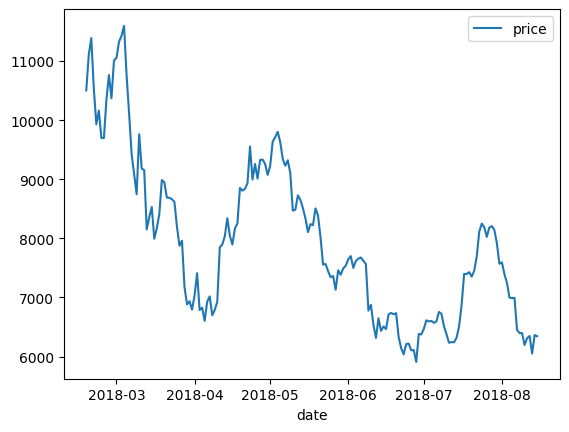

In [50]:
# eyeball test
dfbitcoin.plot.line(x="date",y="price")

In [53]:
# Triple ES
# load data, two issues:
# 1. month is loaded as index
# 2. convert format from wide to long
import pandas as pd
dfairline = pd.read_excel("../data/airline_data.xlsx")
dfairline

,Unnamed: 0,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,January,64.40,65.28,69.77,72.68,72.30,72.95,72.82,74.89,76.55,78.02,78.89
1,February,68.10,68.60,71.58,76.07,75.71,75.91,75.28,77.35,77.92,78.90,80.77
2,March,72.43,75.13,79.58,81.31,81.57,82.19,81.08,83.39,82.70,84.43,84.99
3,April,72.13,76.17,76.64,81.34,81.38,80.09,82.10,82.55,82.13,83.61,82.81
4,May,73.98,74.41,77.52,80.39,81.27,81.34,81.32,82.51,84.58,84.45,84.84
5,June,78.58,80.72,82.27,84.56,86.24,84.24,85.37,86.32,85.98,86.62,86.98
6,July,80.98,82.20,83.94,84.95,86.24,84.11,87.09,86.90,87.14,86.83,86.46
7,August,78.74,78.74,80.34,80.90,84.89,83.35,84.97,85.20,85.59,86.61,85.53
8,September,66.93,70.39,74.12,73.78,75.61,76.07,79.42,79.81,81.82,80.64,80.90
9,October,71.47,74.23,75.94,77.50,78.45,79.76,82.22,83.32,83.63,84.23,82.77


In [54]:
# reset index
dfairline = dfairline.reset_index()
# wide to long
dfairline = pd.melt(dfairline, id_vars=['index'])
# rename
dfairline = dfairline.iloc[12: , :]
dfairline.columns = ["month","year","load"]

In [55]:
dfairline

,month,year,load
12,0,2003,64.4
13,1,2003,68.1
14,2,2003,72.43
15,3,2003,72.13
16,4,2003,73.98
...,...,...,...
139,7,2013,85.53
140,8,2013,80.9
141,9,2013,82.77
142,10,2013,NaN


In [52]:
# de-seasonalize series
#STEP 1: sample average
dfairline["avg"] = dfairline.load.dropna().mean()
#STEP 2: monthly average
# to do this simply, use the transform method, which is a not well understood function in python
# see this post for explanation: http://pbpython.com/pandas_transform.html
dfairline["month_avg"] = pd.to_numeric(dfairline['load']).groupby(dfairline['month']).transform("mean")
#STEP 3: seasonal factor
dfairline["season_factor"] = dfairline.month_avg / dfairline.avg
#STEP 4: de-sesonalized series
dfairline["de_load"] = dfairline.load / dfairline.season_factor
dfairline.head(24)

,month,year,load,avg,month_avg,season_factor,de_load
12,0,2003,64.4,79.444692,72.595455,0.913786,70.476013
13,1,2003,68.1,79.444692,75.108182,0.945415,72.03188
14,2,2003,72.43,79.444692,80.800000,1.017060,71.215087
15,3,2003,72.13,79.444692,80.086364,1.008077,71.552077
16,4,2003,73.98,79.444692,80.600909,1.014554,72.91876
17,5,2003,78.58,79.444692,84.352727,1.061779,74.007849
18,6,2003,80.98,79.444692,85.167273,1.072032,75.538772
19,7,2003,78.74,79.444692,83.169091,1.046880,75.213941
20,8,2003,66.93,79.444692,76.317273,0.960634,69.672737
21,9,2003,71.47,79.444692,79.410909,0.999575,71.500405
